<a href="https://colab.research.google.com/github/elKiruvi/rag-politica-monetaria-banrep/blob/main/Rag_Politica_Monetaria_Banrep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Rag política monetaria Banrep**

## **Descripción:** Sistema RAG con Pinecone
## **Dominio:** Política Monetaria — Banco de la República de Colombia
## **Fuente:** Últimos 5 Informes de Política Monetaria (IPM)

## **Características implementadas:**
- Carga y procesamiento de PDFs (texto puro, sin imágenes)
- Limpieza y normalización de texto financiero
- Detección automática de secciones temáticas
- Chunking estratégico con análisis comparativo
- Comparación de modelos de embeddings (local vs OpenAI)
- Indexación en Pinecone con metadatos enriquecidos
- Búsqueda semántica con filtros por metadatos
- Query Expansion (estándar + HyDE)
- RAG básico con contexto fundamentado
- RAG con reranking mediante Cross-Encoder
- RAG Conversacional con memoria de sesión
- Evaluación automática (faithfulness + relevance)
- Visualización de embeddings con UMAP


## **Instalación y Configuración**


In [ ]:
!pip install -q openai pinecone sentence-transformers \
    langchain langchain-text-splitters umap-learn \
    matplotlib seaborn pandas numpy scikit-learn \
    tiktoken pymupdf

print("Todas las dependencias instaladas correctamente")

import getpass, os

os.environ["OPENAI_API_KEY"]   = getpass.getpass("OpenAI API Key: ")
os.environ["PINECONE_API_KEY"] = getpass.getpass("Pinecone API Key: ")

assert os.environ["OPENAI_API_KEY"],   "OJO: OpenAI API Key no configurada"
assert os.environ["PINECONE_API_KEY"], "OJO: Pinecone API Key no configurada"
print("BIEN! Credenciales configuradas correctamente")

Todas las dependencias instaladas correctamente
OpenAI API Key: ··········
Pinecone API Key: ··········
BIEN! Credenciales configuradas correctamente


In [ ]:
import re, time, json
import fitz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from datetime import datetime
from collections import Counter
from typing import Optional
from pydantic import BaseModel, Field
from transformers import pipeline

from openai import OpenAI
from pinecone import Pinecone, ServerlessSpec
from sentence_transformers import SentenceTransformer, CrossEncoder
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    CharacterTextSplitter,
    SentenceTransformersTokenTextSplitter,
)

client_oai = OpenAI()
pc         = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
np.random.seed(42)

print("Imports y clientes inicializados")
print(f" Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Imports y clientes inicializados
 Timestamp: 2026-04-18 23:08:15


## **PARTE 1:** Carga y Procesamiento de PDFs
### **Fuente:** Informes de Política Monetaria — Banrep

In [ ]:
# ── 1.1  Subir archivos al entorno Colab ───────────────────
print("\n Sube los 5 PDFs de los Informes de Política Monetaria del Banrep")
print("   (panel izquierdo → ícono carpeta → botón subir)\n")

from google.colab import files
uploaded = files.upload()
print(f"\n Archivos recibidos: {list(uploaded.keys())}")

# ── 1.2  Metadatos por reporte ─────────────────────────────

REPORTES_CONFIG = {
    "informe-politica-monetaria-enero-2025.pdf": {"año": 2025, "trimestre": 1, "periodo": "2025-T1"},
    "informe-politica-monetaria-abril-2025.pdf": {"año": 2025, "trimestre": 2, "periodo": "2025-T2"},
    "informe-politica-monetaria-julio-2025.pdf": {"año": 2025, "trimestre": 3, "periodo": "2025-T3"},
    "informe-politica-monetaria-octubre-2025.pdf": {"año": 2025, "trimestre": 4, "periodo": "2025-T4"},
    "informe-politica-monetaria-enero-2026.pdf": {"año": 2026, "trimestre": 1, "periodo": "2026-T1"},
}

# Auto-registrar archivos no configurados
for nombre in uploaded:
    if nombre not in REPORTES_CONFIG:
        print(f"OJO: '{nombre}' no está en REPORTES_CONFIG — se usarán metadatos genéricos.")
        REPORTES_CONFIG[nombre] = {
            "año": 0, "trimestre": 0, "periodo": Path(nombre).stem
        }

# ── 1.3  Keywords para detección de sección temática ───────

print(" Cargando modelo Zero-Shot para clasificación temática...")
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=0 if torch.cuda.is_available() else -1
)

CATEGORIAS_TEMA = [
    "decisión de política monetaria",
    "inflación",
    "actividad económica y crecimiento",
    "sector externo y balanza de pagos",
    "perspectivas y proyecciones",
    "riesgos e incertidumbre",
    "sistema financiero y crédito"
]

MAPEO_CATEGORIAS = {
    "decisión de política monetaria": "decision_politica",
    "inflación": "inflacion",
    "actividad económica y crecimiento": "actividad_economica",
    "sector externo y balanza de pagos": "sector_externo",
    "perspectivas y proyecciones": "perspectivas",
    "riesgos e incertidumbre": "riesgos",
    "sistema financiero y crédito": "sistema_financiero"
}

def detectar_seccion(texto: str) -> str:
    """Clasificación Zero-Shot basada en NLI (Natural Language Inference)."""
    texto_trunc = texto[:800]
    res = zero_shot_classifier(texto_trunc, CATEGORIAS_TEMA, multi_label=False)
    mejor_categoria = res['labels'][0]
    score = res['scores'][0]

    if score < 0.35:
        return "general"

    return MAPEO_CATEGORIAS[mejor_categoria]

# ── 1.4  Limpieza de texto financiero ──────────────────────
def limpiar_texto(texto: str) -> str:
    """
    Limpia el texto crudo extraído del PDF:
      - Colapsa saltos de línea excesivos
      - Elimina números de página aislados
      - Normaliza espacios
      - Descarta líneas de <15 caracteres (leyendas de figuras, etc.)
    """
    texto = re.sub(r'\n{3,}', '\n\n', texto)
    texto = re.sub(r'[ \t]{2,}', ' ', texto)
    texto = re.sub(r'^\s*\d{1,3}\s*$', '', texto, flags=re.MULTILINE)
    lineas = [
        l for l in texto.splitlines()
        if len(l.strip()) > 15 or l.strip() == ''
    ]
    return '\n'.join(lineas).strip()

# ── 1.5  Extracción página a página (imágenes ignoradas) ───
def extraer_texto_pdf(ruta: str, meta: dict) -> list[dict]:
    """
    Extrae texto de un PDF con PyMuPDF.
    `page.get_text('text')` devuelve SOLO texto; las imágenes se omiten.

    Returns:
        Lista de dicts, uno por página con texto útil.
    """
    doc     = fitz.open(ruta)
    paginas = []

    for num_pag, pag in enumerate(doc, start=1):
        texto_raw = pag.get_text("text", sort=True)
        texto     = limpiar_texto(texto_raw)

        if len(texto) < 50:
            continue

        paginas.append({
            "text":      texto,
            "pagina":    num_pag,
            "periodo":   meta["periodo"],
            "año":       meta["año"],
            "trimestre": meta["trimestre"],
        })

    doc.close()
    return paginas

# ── 1.6  Procesar todos los reportes ───────────────────────
PAGINAS_CRUDAS: list[dict] = []

for nombre_archivo, meta in REPORTES_CONFIG.items():
    if nombre_archivo not in uploaded:
        print(f"OJO: Archivo no encontrado en el entorno: {nombre_archivo}")
        continue
    paginas = extraer_texto_pdf(nombre_archivo, meta)
    PAGINAS_CRUDAS.extend(paginas)
    print(f" {nombre_archivo}: {len(paginas)} páginas con texto")

total_chars = sum(len(p["text"]) for p in PAGINAS_CRUDAS)
print(f"\n Extracción completada")
print(f"   Páginas procesadas : {len(PAGINAS_CRUDAS)}")
print(f"   Caracteres totales : {total_chars:,}")
print(f"   Promedio / página  : {total_chars // max(len(PAGINAS_CRUDAS), 1):,} caracteres")

# Distribución por reporte
print("\n Páginas por reporte:")
dist = Counter(p["periodo"] for p in PAGINAS_CRUDAS)
for periodo, n in sorted(dist.items()):
    print(f"   {periodo:<12} {n:>4} páginas  {'█' * (n // 5)}")



 Sube los 5 PDFs de los Informes de Política Monetaria del Banrep
   (panel izquierdo → ícono carpeta → botón subir)



Saving informe-politica-monetaria-abril-2025.pdf to informe-politica-monetaria-abril-2025 (2).pdf
Saving informe-politica-monetaria-enero-2025.pdf to informe-politica-monetaria-enero-2025 (2).pdf
Saving informe-politica-monetaria-enero-2026.pdf to informe-politica-monetaria-enero-2026 (2).pdf
Saving informe-politica-monetaria-julio-2025.pdf to informe-politica-monetaria-julio-2025 (2).pdf
Saving informe-politica-monetaria-octubre-2025.pdf to informe-politica-monetaria-octubre-2025 (2).pdf

 Archivos recibidos: ['informe-politica-monetaria-abril-2025 (2).pdf', 'informe-politica-monetaria-enero-2025 (2).pdf', 'informe-politica-monetaria-enero-2026 (2).pdf', 'informe-politica-monetaria-julio-2025 (2).pdf', 'informe-politica-monetaria-octubre-2025 (2).pdf']
OJO: 'informe-politica-monetaria-abril-2025 (2).pdf' no está en REPORTES_CONFIG — se usarán metadatos genéricos.
OJO: 'informe-politica-monetaria-enero-2025 (2).pdf' no está en REPORTES_CONFIG — se usarán metadatos genéricos.
OJO: 'info

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OJO: Archivo no encontrado en el entorno: informe-politica-monetaria-enero-2025.pdf
OJO: Archivo no encontrado en el entorno: informe-politica-monetaria-abril-2025.pdf
OJO: Archivo no encontrado en el entorno: informe-politica-monetaria-julio-2025.pdf
OJO: Archivo no encontrado en el entorno: informe-politica-monetaria-octubre-2025.pdf
OJO: Archivo no encontrado en el entorno: informe-politica-monetaria-enero-2026.pdf
 informe-politica-monetaria-abril-2025 (2).pdf: 53 páginas con texto
 informe-politica-monetaria-enero-2025 (2).pdf: 60 páginas con texto
 informe-politica-monetaria-enero-2026 (2).pdf: 53 páginas con texto
 informe-politica-monetaria-julio-2025 (2).pdf: 51 páginas con texto
 informe-politica-monetaria-octubre-2025 (2).pdf: 50 páginas con texto

 Extracción completada
   Páginas procesadas : 267
   Caracteres totales : 1,025,950
   Promedio / página  : 3,842 caracteres

 Páginas por reporte:
   informe-politica-monetaria-abril-2025 (2)   53 páginas  ██████████
   informe-

## **PARTE 2:** Chunking Estratégico con Análisis Comparativo

 Documento de prueba: 11230 caracteres
   Extracto: Principales variables del pronóstico macroeconómico

 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027

 Variables exógenas
 PIB socios comercialesb/ Porcentaje, var. anual, corregido por estaci...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 ANÁLISIS COMPARATIVO DE ESTRATEGIAS DE CHUNKING

Estrategia                    N chunks   Avg len     Min     Max
-----------------------------------------------------------------
Fijo sin overlap                    23     487.9     230     500
Recursivo sin overlap               28     399.4     108     485
Recursivo con overlap               28     403.9     108     485
Por tokens (MiniLM)                 45     303.4     247     400


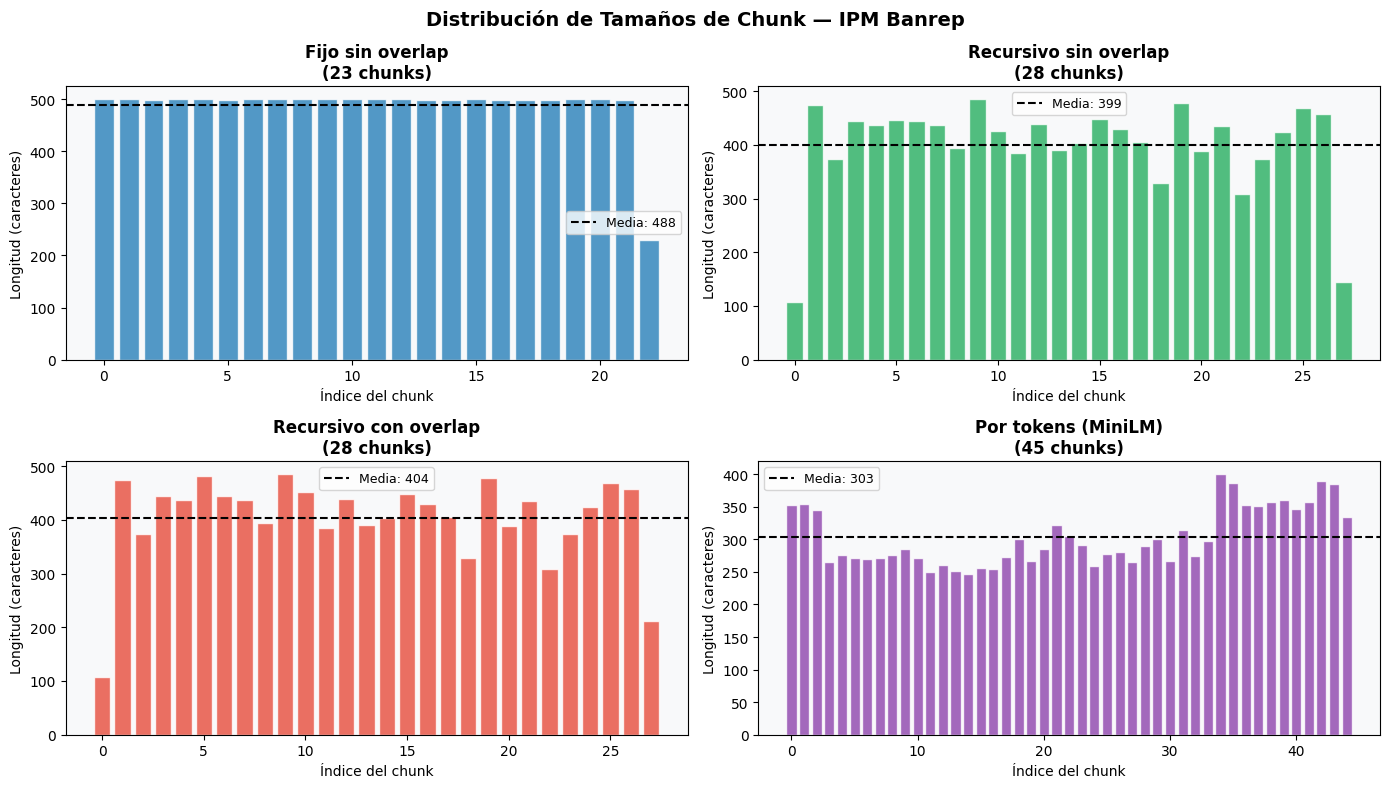


 VERIFICACIÓN DE OVERLAP:
   Fin chunk 0   : '... 2020 2021 2022 2023 2024 2025 2026 2027'
   Inicio chunk 1: 'Variables exógenas
 PIB socios comercial...'

 Estrategia final: Recursivo con overlap (chunk=500, overlap=75)
   Justificación: textos técnicos de política monetaria requieren
   mayor contexto para conservar el significado de los fragmentos.


In [ ]:
# Usamos el texto de la página más larga como documento de prueba
doc_prueba = max(PAGINAS_CRUDAS, key=lambda p: len(p["text"]))["text"]
print(f" Documento de prueba: {len(doc_prueba)} caracteres")
print(f"   Extracto: {doc_prueba[:200]}...\n")
print("=" * 70)

# ── Estrategia 1: Tamaño fijo sin overlap ─────────────────
splitter_fijo = CharacterTextSplitter(
    chunk_size=500, chunk_overlap=0, separator=""
)
chunks_fijo = splitter_fijo.split_text(doc_prueba)

# ── Estrategia 2: Recursivo sin overlap ───────────────────
splitter_rec_noov = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=0,
    separators=["\n\n", "\n", ".", " ", ""]
)
chunks_rec_noov = splitter_rec_noov.split_text(doc_prueba)

# ── Estrategia 3: Recursivo con overlap ───────────────────
# Seleccionada para el RAG final — preserva contexto en los límites
splitter_rec_ov = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=75,
    separators=["\n\n", "\n", ". ", "! ", "? ", " ", ""]
)
chunks_rec_ov = splitter_rec_ov.split_text(doc_prueba)

# ── Estrategia 4: Por tokens ───────────────────────────────
splitter_tok = SentenceTransformersTokenTextSplitter(
    chunk_overlap=15,
    tokens_per_chunk=120,
    model_name="all-MiniLM-L6-v2"
)
chunks_tok = splitter_tok.split_text(doc_prueba)

# ── Análisis comparativo ───────────────────────────────────
estrategias = {
    "Fijo sin overlap":      chunks_fijo,
    "Recursivo sin overlap": chunks_rec_noov,
    "Recursivo con overlap": chunks_rec_ov,
    "Por tokens (MiniLM)":   chunks_tok,
}

print("\n ANÁLISIS COMPARATIVO DE ESTRATEGIAS DE CHUNKING\n")
print(f"{'Estrategia':<28} {'N chunks':>9} {'Avg len':>9} {'Min':>7} {'Max':>7}")
print("-" * 65)
for nombre, chunks in estrategias.items():
    lens = [len(c) for c in chunks]
    print(f"{nombre:<28} {len(chunks):>9} {np.mean(lens):>9.1f} "
          f"{min(lens):>7} {max(lens):>7}")

# ── Visualización ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    "Distribución de Tamaños de Chunk — IPM Banrep",
    fontsize=14, fontweight='bold'
)
colores = ['#2980b9', '#27ae60', '#e74c3c', '#8e44ad']

for ax, (nombre, chunks), color in zip(axes.flat, estrategias.items(), colores):
    lens = [len(c) for c in chunks]
    ax.bar(range(len(lens)), lens, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(np.mean(lens), color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {np.mean(lens):.0f}')
    ax.set_title(f"{nombre}\n({len(chunks)} chunks)", fontweight='bold')
    ax.set_xlabel("Índice del chunk")
    ax.set_ylabel("Longitud (caracteres)")
    ax.legend(fontsize=9)
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig("chunking_comparativo_ipm.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Verificar overlap ─────────────────────────────────────
print("\n VERIFICACIÓN DE OVERLAP:")
print(f"   Fin chunk 0   : '...{chunks_rec_ov[0][-40:]}'")
print(f"   Inicio chunk 1: '{chunks_rec_ov[1][:40]}...'")
print("\n Estrategia final: Recursivo con overlap (chunk=500, overlap=75)")
print("   Justificación: textos técnicos de política monetaria requieren")
print("   mayor contexto para conservar el significado de los fragmentos.")

CHUNKER_FINAL = RecursiveCharacterTextSplitter(
    chunk_size=2000,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", ". ", "! ", "? ", " ", ""]
)


## **PARTE 3:** Comparación de Modelos de Embeddings

In [ ]:
print(" Cargando modelo local SentenceTransformer...")
model_local = SentenceTransformer("BAAI/bge-m3")
print(" Modelo local cargado (BAAI/bge-m3)")

def get_openai_embeddings(
    texts: list[str],
    model: str = "text-embedding-3-large"
) -> np.ndarray:
    """
    Genera embeddings con la API de OpenAI.

    Args:
        texts : Textos a embeddear.
        model : Modelo de embeddings.
    Returns:
        Array (n, dim).
    """
    resp = client_oai.embeddings.create(input=texts, model=model)
    return np.array([item.embedding for item in resp.data])

# ── Corpus de prueba (dominio: política monetaria) ─────────
docs_prueba = [
    "La Junta Directiva del Banco de la República decidió aumentar la tasa de interés de política monetaria en 25 puntos básicos.",
    "La inflación total en Colombia continuó su tendencia descendente, acercándose a la meta del 3 por ciento.",
    "El crecimiento del PIB en el tercer trimestre fue impulsado principalmente por el consumo de los hogares y la inversión privada.",
    "El déficit de cuenta corriente se redujo en gran parte debido a la caída en las importaciones de bienes de capital.",
    "Los pronósticos del modelo de política monetaria sugieren que la inflación convergerá a la meta en el horizonte de dos años.",
]
queries_prueba = [
    "¿Cuál fue la decisión de política monetaria del Banrep?",
    "¿Cómo se comportó la inflación en Colombia?",
    "¿Cuál fue el crecimiento económico del país?",
    "¿Cuál es la situación de la cuenta corriente?",
    "¿Cuáles son las proyecciones de inflación?",
]

# ── Generar embeddings ─────────────────────────────────────
print("\n Generando embeddings con ambos modelos...")
emb_docs_local = model_local.encode(docs_prueba, normalize_embeddings=True)

emb_docs_oai   = get_openai_embeddings(docs_prueba)
emb_docs_oai_n = emb_docs_oai / np.linalg.norm(emb_docs_oai, axis=1, keepdims=True)

# ── Tabla comparativa ──────────────────────────────────────
print(f"\n{'Query':<52} {'MiniLM':>8} {'OAI-3L':>9}")
print("-" * 73)

resultados_cmp = []
for qi, query in enumerate(queries_prueba):
    eq_l = model_local.encode([query], normalize_embeddings=True)
    eq_o = get_openai_embeddings([query])
    eq_o = eq_o / np.linalg.norm(eq_o)

    sims_l = (emb_docs_local @ eq_l.T).flatten()
    sims_o = (emb_docs_oai_n @ eq_o.T).flatten()

    ok_l = " BIEN!" if np.argmax(sims_l) == qi else " MAL!"
    ok_o = " BIEN!" if np.argmax(sims_o) == qi else " MAL!"

    print(f"{query[:50]:<52} {sims_l[qi]:>5.3f}{ok_l} {sims_o[qi]:>7.3f}{ok_o}")
    resultados_cmp.append({
        "ok_local": np.argmax(sims_l) == qi,
        "ok_oai":   np.argmax(sims_o) == qi,
    })

acc_l = sum(r["ok_local"] for r in resultados_cmp) / len(resultados_cmp)
acc_o = sum(r["ok_oai"]   for r in resultados_cmp) / len(resultados_cmp)

print(f"\n Resultados del 'Smoke Test' (Prueba de validación rápida):")
print(f"   BAAI/bge-m3 (local):      {acc_l:.0%} de acierto exacto en top-1")
print(f"   text-embedding-3-large:   {acc_o:.0%} de acierto exacto en top-1")
print(f"\n *Nota metodológica: Debido al tamaño reducido de esta prueba (n=5),")
print(f" esta métrica es indicativa. Se opta por 'text-embedding-3-large' para")
print(f" garantizar máxima capacidad semántica multilingüe en el RAG final.*")

 Cargando modelo local SentenceTransformer...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

 Modelo local cargado (BAAI/bge-m3)

 Generando embeddings con ambos modelos...

Query                                                  MiniLM    OAI-3L
-------------------------------------------------------------------------
¿Cuál fue la decisión de política monetaria del Ba   0.588 BIEN!   0.739 BIEN!
¿Cómo se comportó la inflación en Colombia?          0.704 BIEN!   0.661 BIEN!
¿Cuál fue el crecimiento económico del país?         0.550 BIEN!   0.552 BIEN!
¿Cuál es la situación de la cuenta corriente?        0.591 BIEN!   0.503 BIEN!
¿Cuáles son las proyecciones de inflación?           0.636 BIEN!   0.571 BIEN!

 Resultados del 'Smoke Test' (Prueba de validación rápida):
   BAAI/bge-m3 (local):      100% de acierto exacto en top-1
   text-embedding-3-large:   100% de acierto exacto en top-1

 *Nota metodológica: Debido al tamaño reducido de esta prueba (n=5),
 esta métrica es indicativa. Se opta por 'text-embedding-3-large' para
 garantizar máxima capacidad semántica multilingüe en 

## **PARTE 4:** Indexación en Pinecone con Metadatos Enriquecidos

In [ ]:
INDEX_NAME     = "banrep-politica-monetaria"
EMBEDDING_DIM  = 3072
EMBEDDING_MODEL = "text-embedding-3-large"

# ── Crear / recrear índice ─────────────────────────────────
indices_existentes = [idx.name for idx in pc.list_indexes()]

if INDEX_NAME in indices_existentes:
    print(f"  Índice '{INDEX_NAME}' ya existe — eliminando para reconstruir...")
    pc.delete_index(INDEX_NAME)
    time.sleep(5)

print(f" Creando índice '{INDEX_NAME}'...")
pc.create_index(
    name=INDEX_NAME,
    dimension=EMBEDDING_DIM,
    metric="cosine",
    spec=ServerlessSpec(cloud="aws", region="us-east-1"),
)

print(" Esperando a que el índice esté disponible...", end="")
while not pc.describe_index(INDEX_NAME).status["ready"]:
    time.sleep(2)
    print(".", end="", flush=True)

print(f"\n Índice '{INDEX_NAME}' listo (dim={EMBEDDING_DIM}, metric=cosine)")
index = pc.Index(INDEX_NAME)

# ── Generar chunks desde las páginas extraídas ─────────────
print("\n Aplicando chunking a los documentos extraídos...")
CHUNKS_FINALES: list[dict] = []

for pag in PAGINAS_CRUDAS:
    sub_chunks = CHUNKER_FINAL.split_text(pag["text"])

    for i, chunk_text in enumerate(sub_chunks):
        if len(chunk_text.strip()) < 80:
            continue

        seccion = detectar_seccion(chunk_text)

        CHUNKS_FINALES.append({
            "id":          f"{pag['periodo']}-p{pag['pagina']:04d}-c{i:03d}",
            "text":        chunk_text,
            "periodo":     pag["periodo"],
            "año":         pag["año"],
            "trimestre":   pag["trimestre"],
            "pagina":      pag["pagina"],
            "chunk_index": i,
            "n_chunks_pag": len(sub_chunks),
            "seccion":     seccion,
        })

print(f" Chunks generados    : {len(CHUNKS_FINALES)}")
print(f" Páginas fuente      : {len(PAGINAS_CRUDAS)}")
print(f" Promedio / página   : {len(CHUNKS_FINALES)/max(len(PAGINAS_CRUDAS),1):.1f} chunks")

# Distribución por sección temática
dist_sec = Counter(c["seccion"] for c in CHUNKS_FINALES)
print("\n Chunks por sección temática:")
for sec, n in dist_sec.most_common():
    barra = '█' * (n // max(len(CHUNKS_FINALES) // 40, 1))
    print(f"   {sec:<25} {n:>5}  {barra}")

# ── Embeddings en lotes ────────────────────────────────────
print("\n Generando embeddings (text-embedding-3-large)...")
BATCH_EMB  = 20
all_embeddings: list[np.ndarray] = []

for i in range(0, len(CHUNKS_FINALES), BATCH_EMB):
    batch_textos = [c["text"] for c in CHUNKS_FINALES[i:i + BATCH_EMB]]
    embs = get_openai_embeddings(batch_textos, model=EMBEDDING_MODEL)
    all_embeddings.extend(embs)
    progreso = min(i + BATCH_EMB, len(CHUNKS_FINALES))
    print(f"   {progreso:>5}/{len(CHUNKS_FINALES)} chunks procesados", end="\r")
    time.sleep(0.3)    # evitar rate-limit

print(f"\n {len(all_embeddings)} embeddings generados")

# ── Upsert a Pinecone ──────────────────────────────────────
print("\n Subiendo vectores a Pinecone...")
BATCH_UPSERT = 100
vectors_pinecone = [
    {
        "id":     chunk["id"],
        "values": emb.tolist(),
        "metadata": {
            "text":        chunk["text"],
            "periodo":     chunk["periodo"],
            "año":         chunk["año"],
            "trimestre":   chunk["trimestre"],
            "pagina":      chunk["pagina"],
            "seccion":     chunk["seccion"],
            "chunk_index": chunk["chunk_index"],
        },
    }
    for chunk, emb in zip(CHUNKS_FINALES, all_embeddings)
]

for i in range(0, len(vectors_pinecone), BATCH_UPSERT):
    batch = vectors_pinecone[i:i + BATCH_UPSERT]
    index.upsert(vectors=batch)
    print(f"   Batch {i // BATCH_UPSERT + 1:>3}: {len(batch)} vectores subidos")
    time.sleep(0.5)

time.sleep(4)
stats = index.describe_index_stats()
print(f"\n Indexación completada:")
print(f"   Vectores en el índice : {stats.total_vector_count}")
print(f"   Dimensión             : {stats.dimension}")


  Índice 'banrep-politica-monetaria' ya existe — eliminando para reconstruir...
 Creando índice 'banrep-politica-monetaria'...
 Esperando a que el índice esté disponible...
 Índice 'banrep-politica-monetaria' listo (dim=3072, metric=cosine)

 Aplicando chunking a los documentos extraídos...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


 Chunks generados    : 785
 Páginas fuente      : 267
 Promedio / página   : 2.9 chunks

 Chunks por sección temática:
   perspectivas                232  ████████████
   general                     142  ███████
   actividad_economica         100  █████
   inflacion                    92  ████
   decision_politica            78  ████
   riesgos                      77  ████
   sector_externo               42  ██
   sistema_financiero           22  █

 Generando embeddings (text-embedding-3-large)...

 785 embeddings generados

 Subiendo vectores a Pinecone...
   Batch   1: 100 vectores subidos
   Batch   2: 100 vectores subidos
   Batch   3: 100 vectores subidos
   Batch   4: 100 vectores subidos
   Batch   5: 100 vectores subidos
   Batch   6: 100 vectores subidos
   Batch   7: 100 vectores subidos
   Batch   8: 85 vectores subidos

 Indexación completada:
   Vectores en el índice : 785
   Dimensión             : 3072


## **PARTE 5:** Búsqueda Semántica con Filtros por Metadatos

In [ ]:
def buscar_pinecone(
    pregunta: str,
    k: int = 5,
    filtro: Optional[dict] = None,
    verbose: bool = True,
) -> list[dict]:
    """
    Búsqueda semántica en Pinecone con soporte de filtros de metadatos.

    Args:
        pregunta : Consulta en lenguaje natural.
        k        : Número de resultados.
        filtro   : Filtros de metadatos Pinecone (dict, opcional).
        verbose  : Imprime tabla de resultados.

    Returns:
        Lista de dicts con 'text', 'score' y metadatos.
    """
    emb_q = get_openai_embeddings([pregunta], model=EMBEDDING_MODEL)[0].tolist()

    query_kwargs: dict = {
        "vector": emb_q,
        "top_k": k,
        "include_metadata": True,
    }
    if filtro:
        query_kwargs["filter"] = filtro

    res = index.query(**query_kwargs)

    resultados = []
    for m in res.matches:
        resultados.append({
            "id":        m.id,
            "text":      m.metadata["text"],
            "score":     m.score,
            "periodo":   m.metadata.get("periodo", "—"),
            "seccion":   m.metadata.get("seccion", "—"),
            "pagina":    m.metadata.get("pagina", "—"),
        })

    if verbose:
        filtro_str = f"  [filtro: {filtro}]" if filtro else ""
        print(f"\n '{pregunta}'{filtro_str}\n")
        print(f"{'#':<3} {'Score':>6}  {'Periodo':<12} {'Sección':<25} {'Pág':>4}  Texto")
        print("─" * 100)
        for i, r in enumerate(resultados):
            snippet = r["text"][:55].replace("\n", " ")
            print(f"{i+1:<3} {r['score']:>6.4f}  "
                  f"{r['periodo']:<12} {r['seccion']:<25} {str(r['pagina']):>4}  {snippet}...")

    return resultados


# ── Pruebas de búsqueda ────────────────────────────────────
sep = "=" * 100

print(sep)
print("TEST 1 — Sin filtros: decisión de tasa de interés")
buscar_pinecone("¿Cuál fue la decisión sobre la tasa de interés de política monetaria?")

print(f"\n{sep}")
print("TEST 2 — Filtro por sección: inflación")
buscar_pinecone(
    "¿Cuál fue el comportamiento de la inflación y sus determinantes?",
    filtro={"seccion": "inflacion"}
)

print(f"\n{sep}")
print("TEST 3 — Filtro por año 2026")
buscar_pinecone(
    "¿Cuáles son las perspectivas macroeconómicas?",
    k=4,
    filtro={"año": 2026}
)

print(f"\n{sep}")
print("TEST 4 — Filtro combinado: sector externo en 2025")
buscar_pinecone(
    "Comportamiento de la balanza de pagos y cuenta corriente",
    k=4,
    filtro={"$and": [{"seccion": "sector_externo"}, {"año": 2025}]}
)

print(f"\n{sep}")
print("TEST 5 — Filtro por trimestre: T4 2025")
buscar_pinecone(
    "¿Cuáles fueron los principales riesgos identificados?",
    k=4,
    filtro={"$and": [{"año": 2025}, {"trimestre": 4}]}
)

TEST 1 — Sin filtros: decisión de tasa de interés

 '¿Cuál fue la decisión sobre la tasa de interés de política monetaria?'

#    Score  Periodo      Sección                    Pág  Texto
────────────────────────────────────────────────────────────────────────────────────────────────────
1   0.6405  informe-politica-monetaria-enero-2026 (2) decision_politica           11  Gráfico 1.5 1.2 Decisión de política monetaria Tasa de ...
2   0.6266  informe-politica-monetaria-octubre-2025 (2) inflacion                   11  rápido de lo estimado en el Informe anterior. El deteri...
3   0.6229  informe-politica-monetaria-abril-2025 (2) decision_politica           12  Gráfco 1.5 1.2 Decisión de política monetaria Tasa de i...
4   0.6170  informe-politica-monetaria-julio-2025 (2) decision_politica           12  en 2025 y 2026 a los proyectados en el Informe de abril...
5   0.6114  informe-politica-monetaria-enero-2025 (2) decision_politica           11  Hacia adelante se espera que la infación co

[]

## **PARTE 6:** Query Expansion — Estándar + HyDE

- Query Expansion amplía la consulta para mejorar el recall.
- HyDE (Hypothetical Document Embeddings) genera un fragmento hipotético del documento y lo usa como vector de búsqueda.

In [ ]:
def expandir_query_estandar(pregunta: str) -> list[str]:
    """
    Genera variaciones léxicas y sinónimos de la consulta
    usando GPT para cubrir distintas formulaciones del mismo concepto.

    Returns:
        Lista con la consulta original + 3 variaciones.
    """
    prompt = f"""Eres un experto en política monetaria colombiana.
Dado que el usuario pregunta: "{pregunta}"

Genera exactamente 3 formulaciones alternativas de esta misma pregunta
usando terminología técnica del Banco de la República de Colombia.
Varía el vocabulario pero mantén el significado. Responde SOLO con
las 3 preguntas alternativas, una por línea, sin numeración."""

    resp = client_oai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.4,
        max_tokens=200,
    )
    variaciones = [
        l.strip()
        for l in resp.choices[0].message.content.strip().splitlines()
        if l.strip()
    ][:3]

    return [pregunta] + variaciones


def hyde_query(pregunta: str) -> str:
    prompt = f"""Eres redactor de los Informes de Política Monetaria
del Banco de la República de Colombia. Escribe un párrafo técnico
(máximo 150 palabras) tal como aparecería en uno de esos informes,
que responda directamente a la siguiente pregunta:

Pregunta: {pregunta}

REGLAS ESTRICTAS:
1. Usa el estilo y la terminología oficial del Banrep.
2. NO INVENTES NINGÚN NÚMERO, PORCENTAJE NI FECHA EXACTA. Usa placeholders como "X%" o céntrate puramente en la dirección de las tendencias (ej. "la inflación disminuyó", "la tasa aumentó").
3. Responde SOLO con el párrafo hipotético."""

    resp = client_oai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2, # Bajamos temperatura para menor creatividad
        max_tokens=220,
    )
    return resp.choices[0].message.content.strip()


def buscar_con_expansion(
    pregunta: str,
    k: int = 5,
    filtro: Optional[dict] = None,
    usar_hyde: bool = False,
    verbose: bool = True,
) -> list[dict]:
    """
    Búsqueda con Query Expansion o HyDE.

    Flujo:
      1. Genera variaciones de la consulta (estándar) o un documento
         hipotético (HyDE).
      2. Embeddea cada variación / el hipotético.
      3. Hace búsqueda individual en Pinecone.
      4. Fusiona resultados por puntuación máxima (score fusion).
      5. Devuelve los top-k chunks únicos.

    Args:
        pregunta   : Consulta original.
        k          : Resultados finales.
        filtro     : Filtros de metadatos.
        usar_hyde  : True → HyDE | False → variaciones estándar.
        verbose    : Imprime detalles.

    Returns:
        Lista de dicts con los resultados fusionados.
    """
    if usar_hyde:
        doc_hipotetico = hyde_query(pregunta)
        queries_expandidas = [doc_hipotetico]
        metodo = "HyDE"
        if verbose:
            print(f"\n Documento hipotético generado (HyDE):")
            print(f"   {doc_hipotetico[:200]}...")
    else:
        queries_expandidas = expandir_query_estandar(pregunta)
        metodo = "Query Expansion"
        if verbose:
            print(f"\n Variaciones generadas ({metodo}):")
            for i, q in enumerate(queries_expandidas):
                print(f"   {i+1}. {q}")

    rrf_scores: dict[str, float] = {}
    chunks_data: dict[str, dict] = {}

    for q in queries_expandidas:
        emb = get_openai_embeddings([q], model=EMBEDDING_MODEL)[0].tolist()
        query_kwargs: dict = {
            "vector": emb,
            "top_k": k + 3,
            "include_metadata": True,
        }
        if filtro:
            query_kwargs["filter"] = filtro

        res = index.query(**query_kwargs)

        for rank, m in enumerate(res.matches, start=1):
            cid = m.id
            if cid not in rrf_scores:
                rrf_scores[cid] = 0.0
                chunks_data[cid] = {
                    "id":      cid,
                    "text":    m.metadata["text"],
                    "periodo": m.metadata.get("periodo", "—"),
                    "seccion": m.metadata.get("seccion", "—"),
                    "pagina":  m.metadata.get("pagina", "—"),
                }
            rrf_scores[cid] += 1.0 / (60 + rank)

    resultados = []
    for cid in sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:k]:
        datos = chunks_data[cid]
        datos["score"] = rrf_scores[cid]
        resultados.append(datos)

    if verbose:
        print(f"\n Resultados fusionados ({metodo}) — '{pregunta[:60]}'\n")
        print(f"{'#':<3} {'Score RRF':>9}  {'Periodo':<12} {'Sección':<25}  Texto")
        print("─" * 95)
        for i, r in enumerate(resultados):
            snippet = r["text"][:55].replace("\n", " ")
            print(f"{i+1:<3} {r['score']:>9.4f}  "
                  f"{r['periodo']:<12} {r['seccion']:<25}  {snippet}...")

    return resultados


# ── Comparación de métodos de expansión ───────────────────
pregunta_test = "¿Cuál fue la trayectoria de la inflación y cómo respondió la política monetaria?"

print(sep)
print("COMPARACIÓN: Búsqueda directa vs Query Expansion vs HyDE")

print("\n[A] Búsqueda directa (sin expansión)")
res_directo = buscar_pinecone(pregunta_test, k=4)

print(f"\n[B] Query Expansion (variaciones léxicas)")
res_expansion = buscar_con_expansion(pregunta_test, k=4, usar_hyde=False)

print(f"\n[C] HyDE (documento hipotético)")
res_hyde = buscar_con_expansion(pregunta_test, k=4, usar_hyde=True)

# Métricas de cobertura (chunks únicos recuperados)
ids_directo   = {r["text"][:50] for r in res_directo}
ids_expansion = {r["text"][:50] for r in res_expansion}
ids_hyde      = {r["text"][:50] for r in res_hyde}

print("\n Diversidad de resultados (chunks únicos vs. búsqueda directa):")
print(f"   Query Expansion nuevos chunks: "
      f"{len(ids_expansion - ids_directo)}/{len(ids_expansion)}")
print(f"   HyDE nuevos chunks:            "
      f"{len(ids_hyde - ids_directo)}/{len(ids_hyde)}")

COMPARACIÓN: Búsqueda directa vs Query Expansion vs HyDE

[A] Búsqueda directa (sin expansión)

 '¿Cuál fue la trayectoria de la inflación y cómo respondió la política monetaria?'

#    Score  Periodo      Sección                    Pág  Texto
────────────────────────────────────────────────────────────────────────────────────────────────────
1   0.5842  informe-politica-monetaria-enero-2026 (2) decision_politica            4  Política monetaria en Colombia  De acuerdo con el manda...
2   0.5842  informe-politica-monetaria-julio-2025 (2) decision_politica            4  Política monetaria en Colombia  De acuerdo con el manda...
3   0.5842  informe-politica-monetaria-octubre-2025 (2) decision_politica            4  Política monetaria en Colombia  De acuerdo con el manda...
4   0.5845  informe-politica-monetaria-enero-2025 (2) decision_politica           10  La postura contractiva de la política monetaria sigue c...

[B] Query Expansion (variaciones léxicas)

 Variaciones generadas (Query

## **PARTE 7:** RAG Básico con Contexto Fundamentado

In [ ]:
SYSTEM_PROMPT_RAG = """Eres un experto en política monetaria del Banco de la República de Colombia.
Respondes preguntas académicas sobre los Informes de Política Monetaria (IPM) del Banrep.

Reglas estrictas:
1. Usa ÚNICAMENTE la información del contexto proporcionado.
2. Si el contexto no contiene información suficiente, indícalo explícitamente.
3. Cita el periodo del informe cuando sea relevante (ej. "Según el IPM 2026-T1...").
4. Usa terminología técnica precisa: tasa de interés de política, inflación básica, etc.
5. No inventes cifras ni datos que no estén en el contexto.
6. IMPORTANTE: Si el contexto tiene cifras que cambian dependiendo del trimestre o año, prioriza y aclara la información del periodo más reciente."""


def construir_contexto(resultados: list[dict], max_chars: int = 10000) -> str:
    """
    Construye el bloque de contexto para el prompt del LLM.
    Se aumentó el límite a 12,000 caracteres para aprovechar GPT-4o.
    Evita cortar palabras por la mitad.
    """
    bloques = []
    chars_usados = 0

    for r in resultados:
        encabezado = (
            f"[IPM {r.get('periodo','?')} | "
            f"Sección: {r.get('seccion','?')} | "
            f"Pág. {r.get('pagina','?')}]"
        )
        bloque = f"{encabezado}\n{r['text']}"

        if chars_usados + len(bloque) > max_chars:
            espacio_disponible = max_chars - chars_usados - len(encabezado) - 5
            if espacio_disponible > 100:
                texto_truncado = r['text'][:espacio_disponible]
                # Buscar el último espacio para no cortar palabras o números
                ultimo_espacio = texto_truncado.rfind(' ')
                if ultimo_espacio != -1:
                    texto_truncado = texto_truncado[:ultimo_espacio]
                bloques.append(f"{encabezado}\n{texto_truncado}…")
            break

        bloques.append(bloque)
        chars_usados += len(bloque)

    return "\n\n---\n\n".join(bloques)


def rag_basico(
    pregunta: str,
    k: int = 5,
    filtro: Optional[dict] = None,
    usar_expansion: bool = True,
    usar_hyde: bool = False,
    verbose: bool = True,
) -> str:
    """
    Pipeline RAG básico:
      Recuperación → Construcción de contexto → Generación.

    Args:
        pregunta       : Consulta del usuario.
        k              : Chunks a recuperar.
        filtro         : Filtros de metadatos Pinecone.
        usar_expansion : Usar query expansion antes de recuperar.
        usar_hyde      : Usar HyDE en lugar de expansion estándar.
        verbose        : Imprimir proceso.
    Returns:
        Respuesta generada por el LLM.
    """
    # ── Recuperación ──────────────────────────────────────
    if usar_expansion:
        resultados = buscar_con_expansion(
            pregunta, k=k, filtro=filtro,
            usar_hyde=usar_hyde, verbose=verbose
        )
    else:
        resultados = buscar_pinecone(
            pregunta, k=k, filtro=filtro, verbose=verbose
        )

    # ── Construcción del contexto ─────────────────────────
    contexto = construir_contexto(resultados)

    if verbose:
        print(f"\n Contexto construido: {len(contexto)} caracteres "
              f"({len(resultados)} chunks)")

    # ── Generación ────────────────────────────────────────
    user_msg = (
        f"CONTEXTO DE LOS INFORMES DE POLÍTICA MONETARIA:\n\n"
        f"{contexto}\n\n"
        f"PREGUNTA: {pregunta}\n\n"
        f"Responde de forma clara y técnica basándote exclusivamente en el contexto."
    )

    resp = client_oai.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_RAG},
            {"role": "user",   "content": user_msg},
        ],
        temperature=0.1,
        max_tokens=600,
    )

    respuesta = resp.choices[0].message.content.strip()

    if verbose:
        print(f"\n{'─'*80}")
        print(" RESPUESTA RAG BÁSICO:")
        print(f"{'─'*80}")
        print(respuesta)
        print(f"{'─'*80}")
        print(f"   Tokens usados: {resp.usage.total_tokens}")

    return respuesta


# ── Pruebas RAG básico ─────────────────────────────────────
print(sep)
print("RAG BÁSICO — Test 1: Decisión de política y tasa de interés")
rag_basico(
    "¿Cuáles fueron las principales razones que llevaron al Banrep "
    "a modificar la tasa de interés de política monetaria?",
    usar_expansion=True, usar_hyde=False,
)

print(f"\n{sep}")
print("RAG BÁSICO — Test 2: Inflación con HyDE")
rag_basico(
    "¿Cómo evolucionó la inflación básica y cuáles fueron sus principales determinantes?",
    usar_expansion=True, usar_hyde=True,
)

print(f"\n{sep}")
print("RAG BÁSICO — Test 3: Perspectivas con filtro temporal")
rag_basico(
    "¿Cuáles son las proyecciones de crecimiento económico e inflación "
    "para los próximos trimestres?",
    filtro={"año": 2026},
    usar_expansion=False,
)

RAG BÁSICO — Test 1: Decisión de política y tasa de interés

 Variaciones generadas (Query Expansion):
   1. ¿Cuáles fueron las principales razones que llevaron al Banrep a modificar la tasa de interés de política monetaria?
   2. ¿Qué factores macroeconómicos influyeron en la decisión del Banco de la República de ajustar la tasa de interés de referencia?
   3. ¿Cuáles fueron los principales determinantes que llevaron al Banrep a realizar un cambio en su política de tasas de interés?
   4. ¿Qué elementos del entorno económico motivaron al Banco de la República a modificar su tasa de interés de política monetaria?

 Resultados fusionados (Query Expansion) — '¿Cuáles fueron las principales razones que llevaron al Banre'

#   Score RRF  Periodo      Sección                    Texto
───────────────────────────────────────────────────────────────────────────────────────────────
1      0.0650  informe-politica-monetaria-enero-2026 (2) decision_politica          natural. La perspectiva de un 

'Lo siento, pero el contexto proporcionado no contiene información específica sobre las proyecciones de crecimiento económico e inflación para los próximos trimestres. Por favor, proporciona más detalles o datos del informe para poder ofrecer una respuesta más precisa.'

## **PARTE 8:** RAG con Reranking (Cross-Encoder)

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"\n Cargando Cross-Encoder en dispositivo: {device.upper()}...")
cross_encoder = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1", device=device)
print(" Cross-Encoder listo para reranking")


def rag_con_reranking(
    pregunta: str,
    k_retrieval: int = 15,
    k_final: int = 5,
    filtro: Optional[dict] = None,
    verbose: bool = True,
) -> str:
    """
    Pipeline RAG con reranking:
      1. Recupera k_retrieval candidatos (con query expansion).
      2. Cross-Encoder re-puntúa cada (pregunta, chunk).
      3. Selecciona los k_final mejores para el contexto.
      4. Genera respuesta con GPT-4o.

    Args:
        pregunta     : Consulta del usuario.
        k_retrieval  : Candidatos iniciales a recuperar.
        k_final      : Chunks seleccionados tras reranking.
        filtro       : Filtros de metadatos Pinecone.
        verbose      : Imprimir proceso y delta de scores.
    Returns:
        Respuesta generada por el LLM.
    """
    # ── Paso 1: Recuperación amplia ────────────────────────
    if verbose:
        print(f"\n Recuperando {k_retrieval} candidatos...")
    candidatos = buscar_con_expansion(
        pregunta, k=k_retrieval, filtro=filtro, verbose=False
    )

    # ── Paso 2: Reranking con Cross-Encoder ───────────────
    pares = [(pregunta, c["text"]) for c in candidatos]
    scores_ce = cross_encoder.predict(pares)

    for cand, score in zip(candidatos, scores_ce):
        cand["score_ce"] = float(score)

    reranked = sorted(candidatos, key=lambda x: x["score_ce"], reverse=True)
    seleccionados = reranked[:k_final]

    if verbose:
        print(f"\n RERANKING — Top {k_final} tras Cross-Encoder:\n")
        print(f"{'#':<3} {'Score orig':>11} {'Score CE':>10}  {'Periodo':<12} {'Sección':<22}  Texto")
        print("─" * 100)
        for i, r in enumerate(seleccionados):
            snippet = r["text"][:50].replace("\n", " ")
            print(f"{i+1:<3} {r['score']:>11.4f} {r['score_ce']:>10.4f}  "
                  f"{r['periodo']:<12} {r['seccion']:<22}  {snippet}...")

        # Mostrar chunks que subieron de rango
        ids_antes   = [c["text"][:40] for c in candidatos[:k_final]]
        ids_despues = [r["text"][:40] for r in seleccionados]
        nuevos = [t for t in ids_despues if t not in ids_antes]
        if nuevos:
            print(f"\n {len(nuevos)} chunks ascendieron por reranking")

    # ── Paso 3: Generación ────────────────────────────────
    contexto = construir_contexto(seleccionados)
    user_msg = (
        f"CONTEXTO (priorizado por relevancia):\n\n{contexto}\n\n"
        f"PREGUNTA: {pregunta}\n\n"
        f"Responde de forma técnica y precisa basándote en el contexto."
    )

    resp = client_oai.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_RAG},
            {"role": "user",   "content": user_msg},
        ],
        temperature=0.1,
        max_tokens=700,
    )

    respuesta = resp.choices[0].message.content.strip()

    if verbose:
        print(f"\n{'─'*80}")
        print(" RESPUESTA RAG + RERANKING:")
        print(f"{'─'*80}")
        print(respuesta)
        print(f"{'─'*80}")
        print(f"   Tokens usados: {resp.usage.total_tokens}")

    return respuesta


# ── Prueba RAG con reranking ───────────────────────────────
print(sep)
print("RAG + RERANKING — Análisis de transmisión de política monetaria")
rag_con_reranking(
    "¿Cómo se ha transmitido la política monetaria a las tasas de "
    "interés del mercado crediticio y cuál ha sido su impacto en "
    "la demanda agregada?",
    k_retrieval=15,
    k_final=5,
)


 Cargando Cross-Encoder en dispositivo: CUDA...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cross-encoder/mmarco-mMiniLMv2-L12-H384-v1
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Cross-Encoder listo para reranking
RAG + RERANKING — Análisis de transmisión de política monetaria

 Recuperando 15 candidatos...

 RERANKING — Top 5 tras Cross-Encoder:

#    Score orig   Score CE  Periodo      Sección                 Texto
────────────────────────────────────────────────────────────────────────────────────────────────────
1        0.0580    -0.3419  informe-politica-monetaria-julio-2025 (2) decision_politica       TPM 13,18 11,75 9,70 9,50 9,25 reflejando la trans...
2        0.0544    -0.6545  informe-politica-monetaria-abril-2025 (2) riesgos                 por parte de los bancos para todas las modalidades...
3        0.0595    -1.1020  informe-politica-monetaria-enero-2026 (2) sistema_financiero      Situación económica actual   3.4 Mercado monetario...
4        0.0596    -1.5755  informe-politica-monetaria-enero-2025 (2) riesgos                 mientras que las modalidades de vivienda y microcr...
5        0.0630    -2.5612  informe-politica-monetaria-enero-202

'Según el IPM de julio de 2025, la transmisión de la política monetaria a las tasas de interés del mercado crediticio ha sido evidente, aunque con ciertas particularidades. Durante el segundo trimestre de 2025, la Junta Directiva del Banco de la República redujo la tasa de interés de política monetaria (TPM) en 25 puntos básicos. Este ajuste se reflejó en las tasas del mercado monetario, especialmente en la tasa interbancaria (TIB) y los indicadores bancarios de referencia (IBR) overnight y a un mes. Sin embargo, la brecha entre la TPM y las tasas IBR a plazos mayores al overnight ha venido reduciéndose, lo que sugiere expectativas de recortes más lentos en la TPM.\n\nEn cuanto a las tasas de interés de captación, como las de los Certificados de Depósito a Término (CDT), mostraron reducciones marginales durante el segundo trimestre, pero a plazos mayores a un año, las tasas de interés de los CDT registraron incrementos. Esto se debe, en parte, a expectativas de menores reducciones en l

## **PARTE 9:** RAG Conversacional con Memoria de Sesión

In [ ]:
class SesionRAG:
    """Sistema RAG conversacional con memoria de sesión y Self-Querying."""

    def __init__(self):
        self.historial: list[dict]  = []
        self.chunks_usados: set[str] = set()
        print(" Nueva sesión RAG conversacional iniciada")

    class FiltroMetadatos(BaseModel):
        años: list[int] = Field(description="Lista de años mencionados. Ej: [2025, 2026]. Vacío si no menciona.")
        secciones: list[str] = Field(description="Lista de secciones mencionadas (inflacion, sector_externo, actividad_economica, riesgos). Vacío si no menciona.")

    def _extraer_filtros_auto(self, pregunta: str) -> dict:
        """Self-Querying: Extrae metadatos usando Structured Outputs de OpenAI."""
        prompt = f"""Extrae metadatos para filtrar una base de datos del Banco de la República.
        Pregunta del usuario: "{pregunta}" """

        try:
            resp = client_oai.beta.chat.completions.parse(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                response_format=self.FiltroMetadatos
            )
            datos = resp.choices[0].message.parsed

            if datos.años:
                return {"año": {"$in": datos.años}}
        except Exception as e:
            pass

        return None

    def preguntar(
        self,
        pregunta: str,
        k: int = 5,
        filtro_manual: Optional[dict] = None,
        usar_reranking: bool = False,
        verbose: bool = True,
    ) -> str:

        if verbose:
            print(f" Usuario: {pregunta}")

        # ── Reformular si hay historial
        pregunta_expandida = self._reformular(pregunta) if self.historial else pregunta
        if verbose and pregunta_expandida != pregunta:
            print(f"   ↳ Reformulada: {pregunta_expandida}")

        # ── Self-Querying (Filtros Automáticos)
        filtro_auto = self._extraer_filtros_auto(pregunta_expandida)
        filtro_final = filtro_manual or filtro_auto
        if verbose and filtro_auto:
            print(f"   ↳ Filtro Automático detectado: {filtro_auto}")

        # ── Recuperación
        if usar_reranking:
            candidatos = buscar_con_expansion(
                pregunta_expandida, k=12, filtro=filtro_final, verbose=False
            )
            pares  = [(pregunta_expandida, c["text"]) for c in candidatos]
            scores = cross_encoder.predict(pares)
            for c, s in zip(candidatos, scores):
                c["score_ce"] = float(s)
            candidatos = sorted(candidatos, key=lambda x: x["score_ce"], reverse=True)[:k]
        else:
            candidatos = buscar_con_expansion(
                pregunta_expandida, k=k, filtro=filtro_final, verbose=False
            )

        # ── Deduplicación exacta por ID de Pinecone
        nuevos     = [c for c in candidatos if c["id"] not in self.chunks_usados]
        repetidos  = [c for c in candidatos if c["id"] in self.chunks_usados]
        seleccion  = (nuevos + repetidos)[:k]

        for c in seleccion:
            self.chunks_usados.add(c["id"])

        contexto = construir_contexto(seleccion)

        # ── Generación
        mensajes = [{"role": "system", "content": SYSTEM_PROMPT_RAG}]
        mensajes += self.historial[-8:]
        mensajes.append({
            "role": "user",
            "content": f"CONTEXTO ACTUAL:\n\n{contexto}\n\nPREGUNTA: {pregunta}"
        })

        resp = client_oai.chat.completions.create(
            model="gpt-4o",
            messages=mensajes,
            temperature=0.15,
            max_tokens=600,
        )
        respuesta = resp.choices[0].message.content.strip()

        # ── Actualizar historial
        self.historial.append({"role": "user",      "content": pregunta})
        self.historial.append({"role": "assistant", "content": respuesta})

        if verbose:
            print(f"\n Asistente: {respuesta}")
            print(f"   [Turno {len(self.historial)//2} | Tokens: {resp.usage.total_tokens} | Chunks nuevos: {len(nuevos)}/{len(seleccion)}]\n")

        return respuesta

    def _reformular(self, pregunta: str) -> str:
        historial_str = "\n".join(f"{'Usuario' if m['role']=='user' else 'Asistente'}: {m['content'][:150]}" for m in self.historial[-4:])
        prompt = f"Historial:\n{historial_str}\n\nReescribe esta pregunta para que sea autónoma (sin referencias implícitas): '{pregunta}'\nResponde SOLO con la pregunta reformulada."
        resp = client_oai.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}], temperature=0.2, max_tokens=120)
        return resp.choices[0].message.content.strip()

    def resumen_sesion(self):
        print(f"\n{'─'*60}\n RESUMEN DE SESIÓN\n{'─'*60}")
        print(f"   Turnos             : {len(self.historial)//2}")
        print(f"   Chunks consultados : {len(self.chunks_usados)}")
        for i, m in enumerate(self.historial):
            if m["role"] == "user": print(f"      {i//2+1}. {m['content'][:70]}...")
        print(f"{'─'*60}")


# ── Demo conversacional ────────────────────────────────────
print(sep)
print("RAG CONVERSACIONAL — Simulación de sesión académica\n")

sesion = SesionRAG()

sesion.preguntar(
    "¿Cuál fue la postura de política monetaria del Banrep "
    "y en qué nivel se ubicó la tasa de interés de política?"
)

sesion.preguntar(
    "¿Y cuáles fueron las razones principales detrás de esa decisión?"
)

sesion.preguntar(
    "¿Cómo se comportó la inflación básica durante ese periodo "
    "y cómo se compara con la meta del 3%?"
)

sesion.preguntar(
    "¿Qué riesgos externos identificó el Banco que podrían afectar "
    "el cumplimiento de la meta de inflación?",
    usar_reranking=True,
)

sesion.resumen_sesion()

RAG CONVERSACIONAL — Simulación de sesión académica

 Nueva sesión RAG conversacional iniciada
 Usuario: ¿Cuál fue la postura de política monetaria del Banrep y en qué nivel se ubicó la tasa de interés de política?

 Asistente: Según el IPM de enero de 2026, la postura de política monetaria del Banco de la República fue de ajuste al alza. En su reunión de enero de 2026, la Junta Directiva del Banco de la República decidió aumentar la tasa de interés de política en 100 puntos básicos, ubicándola en el 10,25%.
   [Turno 1 | Tokens: 2089 | Chunks nuevos: 5/5]

 Usuario: ¿Y cuáles fueron las razones principales detrás de esa decisión?
   ↳ Reformulada: ¿Cuáles fueron las razones principales detrás de la decisión de ajuste al alza en la política monetaria?

 Asistente: Según el IPM de enero de 2026, la decisión de ajustar al alza la postura de política monetaria del Banco de la República se fundamentó en varios factores clave:

1. **Aumento de la Inflación**: Se proyecta un incremento en la

## **PARTE 10:** Evaluación Automática (Faithfulness + Relevance)

EVALUACIÓN AUTOMÁTICA — Suite de 6 casos

──────────────────────────────────────────────────────────────────────
 Caso 1/6: ¿Cuál fue la decisión de la Junta Directiva sobre la tasa de inte...
   Faithfulness : 9/10  BIEN!
   Relevance    : 9/10
   Global       : aceptable
   Respuesta    : Según el IPM de enero de 2026, la Junta Directiva del Banco de la República decidió, por mayoría, mantener inalterada la...

──────────────────────────────────────────────────────────────────────
 Caso 2/6: ¿Cómo evolucionó la inflación total y básica respecto a la meta d...
   Faithfulness : 9/10  BIEN!
   Relevance    : 9/10
   Global       : aceptable
   Respuesta    : Según el IPM de julio de 2025, la inflación total anual en Colombia ha mostrado una tendencia descendente, situándose en...

──────────────────────────────────────────────────────────────────────
 Caso 3/6: ¿Cuáles fueron las proyecciones de crecimiento del PIB y qué fact...
   Faithfulness : 9/10  BIEN!
   Relevance    : 9/10
   G

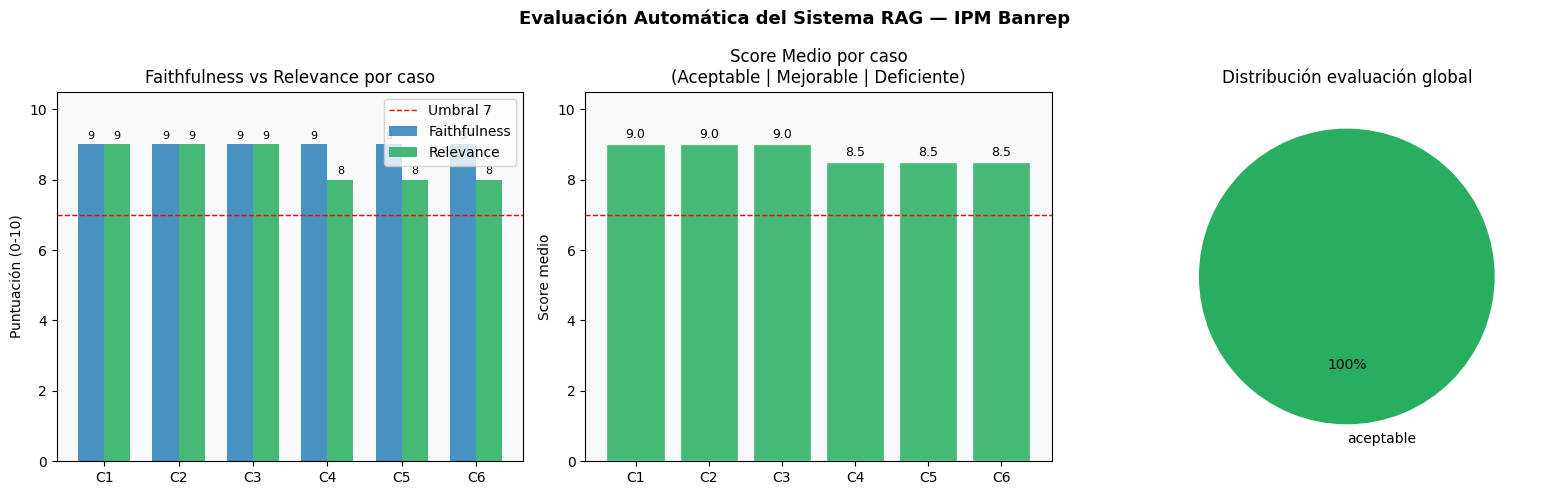

In [ ]:
class MetricaEval(BaseModel):
    score: int = Field(description="Puntuación de 0 a 10")
    justificacion: str = Field(description="Justificación breve, máximo 80 palabras")

class EvaluacionFaithfulness(MetricaEval):
    contiene_alucinaciones: bool

class EvaluacionRelevance(MetricaEval):
    aspectos_no_cubiertos: str

class EvaluacionRAG(BaseModel):
    faithfulness: EvaluacionFaithfulness
    relevance: EvaluacionRelevance
    evaluacion_global: str = Field(description="Valores permitidos: aceptable, mejorable, deficiente")

def evaluar_respuesta(pregunta: str, respuesta: str, contexto: str) -> dict:
    prompt = f"""Evalúa la respuesta de un sistema RAG sobre política monetaria.

PREGUNTA: {pregunta}

CONTEXTO RECUPERADO:
{contexto}

RESPUESTA GENERADA:
{respuesta}
"""
    resp = client_oai.beta.chat.completions.parse(
        model="gpt-4o",
        messages=[{"role": "system", "content": "Eres un juez experto evaluando sistemas RAG."},
                  {"role": "user", "content": prompt}],
        temperature=0.0,
        response_format=EvaluacionRAG,
    )

    return resp.choices[0].message.parsed.model_dump()


def evaluar_suite_completa(
    casos: list[dict],
    usar_reranking: bool = True,
) -> pd.DataFrame:
    """
    Ejecuta el pipeline RAG completo y evalúa cada caso de prueba.

    Args:
        casos          : Lista de dicts con 'pregunta' y opcionalmente 'filtro'.
        usar_reranking : Usar reranking en la recuperación.
    Returns:
        DataFrame con métricas por caso.
    """
    resultados = []

    for i, caso in enumerate(casos):
        print(f"\n{'─'*70}")
        print(f" Caso {i+1}/{len(casos)}: {caso['pregunta'][:65]}...")

        filtro = caso.get("filtro")

        # Recuperación
        if usar_reranking:
            chunks = buscar_con_expansion(
                caso["pregunta"], k=12, filtro=filtro, verbose=False
            )
            pares  = [(caso["pregunta"], c["text"]) for c in chunks]
            scores = cross_encoder.predict(pares)
            for c, s in zip(chunks, scores):
                c["score_ce"] = float(s)
            chunks = sorted(chunks, key=lambda x: x["score_ce"], reverse=True)[:5]
        else:
            chunks = buscar_con_expansion(
                caso["pregunta"], k=5, filtro=filtro, verbose=False
            )

        contexto  = construir_contexto(chunks)
        user_msg  = (
            f"CONTEXTO:\n\n{contexto}\n\n"
            f"PREGUNTA: {caso['pregunta']}\n\n"
            f"Responde de forma técnica y precisa."
        )
        resp_llm = client_oai.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_RAG},
                {"role": "user",   "content": user_msg},
            ],
            temperature=0.1,
            max_tokens=500,
        )
        respuesta = resp_llm.choices[0].message.content.strip()

        # Evaluación
        eval_res = evaluar_respuesta(caso["pregunta"], respuesta, contexto)

        faith = eval_res["faithfulness"]
        relev = eval_res["relevance"]

        print(f"   Faithfulness : {faith['score']}/10"
              f"  {'OJO: ALUCINACIÓN' if faith['contiene_alucinaciones'] else 'BIEN!'}")
        print(f"   Relevance    : {relev['score']}/10")
        print(f"   Global       : {eval_res['evaluacion_global']}")
        print(f"   Respuesta    : {respuesta[:120]}...")

        resultados.append({
            "caso":               i + 1,
            "pregunta":           caso["pregunta"][:60],
            "faithfulness":       faith["score"],
            "alucinacion":        faith["contiene_alucinaciones"],
            "relevance":          relev["score"],
            "global":             eval_res["evaluacion_global"],
            "score_medio":        (faith["score"] + relev["score"]) / 2,
        })

        time.sleep(1)

    return pd.DataFrame(resultados)


# ── Suite de evaluación ────────────────────────────────────
CASOS_EVALUACION = [
    {
        "pregunta": "¿Cuál fue la decisión de la Junta Directiva sobre la tasa de interés y cuáles fueron sus fundamentos?",
    },
    {
        "pregunta": "¿Cómo evolucionó la inflación total y básica respecto a la meta del 3%?",
        "filtro": {"seccion": "inflacion"},
    },
    {
        "pregunta": "¿Cuáles fueron las proyecciones de crecimiento del PIB y qué factores las determinaron?",
        "filtro": {"seccion": "actividad_economica"},
    },
    {
        "pregunta": "¿Cuál fue la evolución de la cuenta corriente y la tasa de cambio del peso colombiano?",
        "filtro": {"seccion": "sector_externo"},
    },
    {
        "pregunta": "¿Qué riesgos internos y externos identificó el Banrep en su balance de riesgos?",
        "filtro": {"seccion": "riesgos"},
    },
    {
        "pregunta": "¿Cómo se transmitió la política monetaria al crédito y al mercado financiero?",
        "filtro": {"seccion": "sistema_financiero"},
    },
]

print(sep)
print("EVALUACIÓN AUTOMÁTICA — Suite de 6 casos")
df_eval = evaluar_suite_completa(CASOS_EVALUACION, usar_reranking=True)

# ── Tabla de resultados ────────────────────────────────────
print(f"\n\n{'═'*75}")
print(" RESULTADOS GLOBALES DE EVALUACIÓN")
print(f"{'═'*75}")
print(df_eval[["caso","pregunta","faithfulness","relevance",
               "alucinacion","global","score_medio"]].to_string(index=False))

print(f"\n{'─'*50}")
print(f"   Faithfulness media : {df_eval['faithfulness'].mean():.2f}/10")
print(f"   Relevance media    : {df_eval['relevance'].mean():.2f}/10")
print(f"   Score medio global : {df_eval['score_medio'].mean():.2f}/10")
print(f"   Alucinaciones      : {df_eval['alucinacion'].sum()}/{len(df_eval)} casos")
print(f"   Casos aceptables   : {(df_eval['global']=='aceptable').sum()}/{len(df_eval)}")

# ── Visualización de métricas ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Evaluación Automática del Sistema RAG — IPM Banrep",
             fontsize=13, fontweight='bold')

# Faithfulness vs Relevance
ax = axes[0]
x = np.arange(len(df_eval))
w = 0.35
bars1 = ax.bar(x - w/2, df_eval["faithfulness"], w, label="Faithfulness",
               color="#2980b9", alpha=0.85)
bars2 = ax.bar(x + w/2, df_eval["relevance"],    w, label="Relevance",
               color="#27ae60", alpha=0.85)
ax.axhline(7, color="red", linestyle="--", linewidth=1, label="Umbral 7")
ax.set_xticks(x)
ax.set_xticklabels([f"C{i+1}" for i in range(len(df_eval))])
ax.set_ylim(0, 10.5)
ax.set_title("Faithfulness vs Relevance por caso")
ax.set_ylabel("Puntuación (0-10)")
ax.legend()
ax.set_facecolor('#f8f9fa')
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.0f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.0f}", ha='center', va='bottom', fontsize=8)

# Score medio
ax = axes[1]
colores_global = [
    "#27ae60" if g == "aceptable" else
    "#f39c12" if g == "mejorable" else "#e74c3c"
    for g in df_eval["global"]
]
bars = ax.bar(x, df_eval["score_medio"], color=colores_global, alpha=0.85,
              edgecolor='white')
ax.axhline(7, color="red", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([f"C{i+1}" for i in range(len(df_eval))])
ax.set_ylim(0, 10.5)
ax.set_title("Score Medio por caso\n(Aceptable | Mejorable | Deficiente)")
ax.set_ylabel("Score medio")
ax.set_facecolor('#f8f9fa')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=9)

# Distribución de evaluación global
ax = axes[2]
counts = df_eval["global"].value_counts()
colores_pie = {"aceptable": "#27ae60", "mejorable": "#f39c12", "deficiente": "#e74c3c"}
ax.pie(
    counts.values,
    labels=counts.index,
    colors=[colores_pie.get(l, "#95a5a6") for l in counts.index],
    autopct='%1.0f%%', startangle=90,
    textprops={"fontsize": 10}
)
ax.set_title("Distribución evaluación global")

plt.tight_layout()
plt.savefig("evaluacion_rag_ipm.png", dpi=150, bbox_inches='tight')
plt.show()

## **PARTE 11:** Visualización de Embeddings con UMAP

 Preparando visualización UMAP de embeddings...
   Muestra: 300 chunks para UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 Reducción UMAP completada


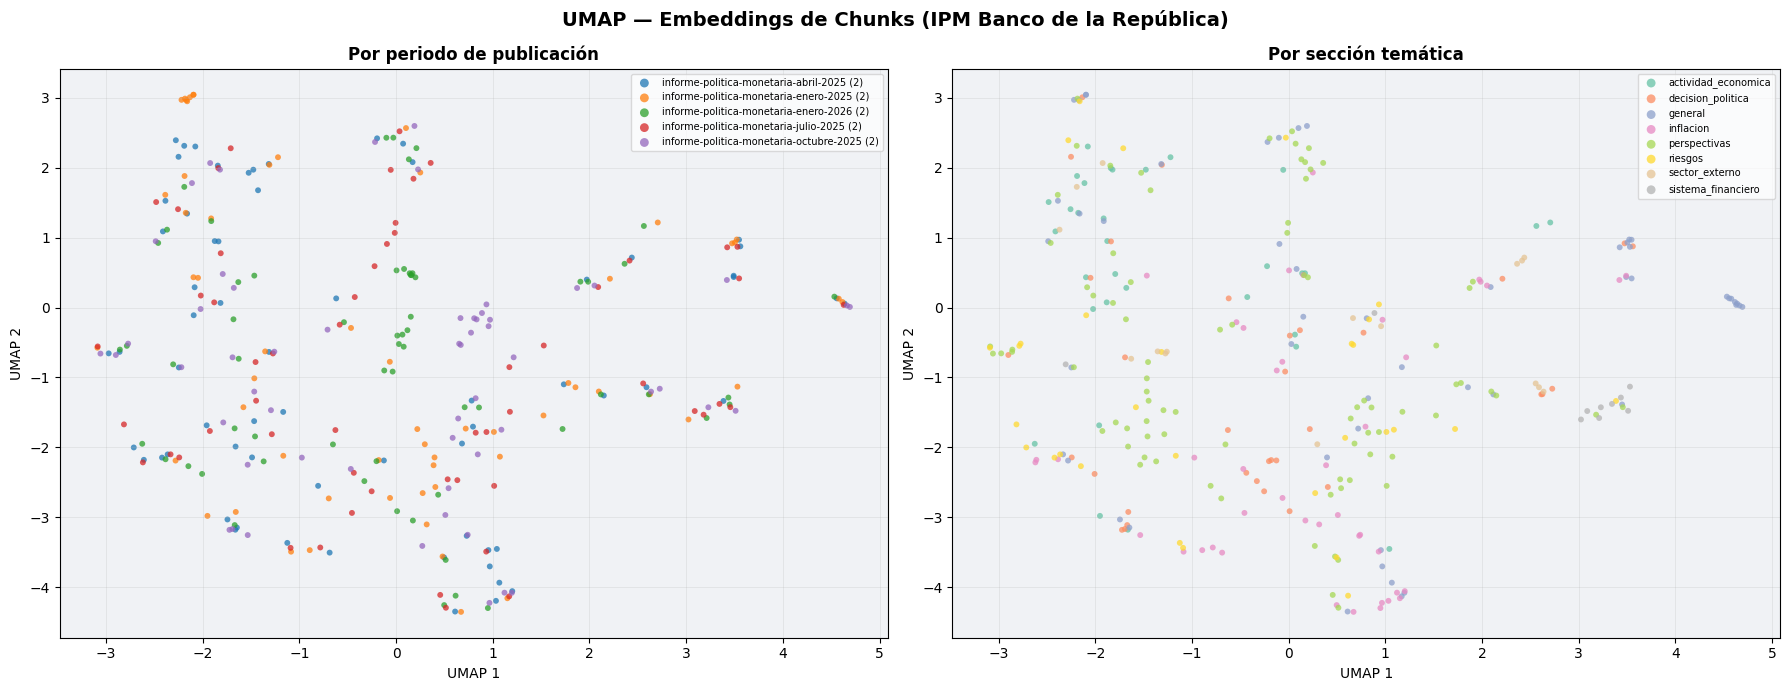

 Visualización UMAP guardada


In [ ]:
try:
    import umap
    UMAP_DISPONIBLE = True
except ImportError:
    print(" umap-learn no disponible — instalando...")
    os.system("pip install -q umap-learn")
    import umap
    UMAP_DISPONIBLE = True

print(" Preparando visualización UMAP de embeddings...")

MAX_UMAP = min(300, len(CHUNKS_FINALES))
indices_muestra = np.random.choice(len(CHUNKS_FINALES), MAX_UMAP, replace=False)
chunks_muestra  = [CHUNKS_FINALES[i] for i in indices_muestra]
embs_muestra    = np.array([all_embeddings[i] for i in indices_muestra])

print(f"   Muestra: {MAX_UMAP} chunks para UMAP")

# ── Reducción UMAP ────────────────────────────────────────
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
embs_2d = reducer.fit_transform(embs_muestra)
print(" Reducción UMAP completada")

# ── Plot 1: Colorear por periodo ──────────────────────────
periodos      = sorted(set(c["periodo"] for c in chunks_muestra))
palette_per   = sns.color_palette("tab10", len(periodos))
color_map_per = {p: palette_per[i] for i, p in enumerate(periodos)}

# ── Plot 2: Colorear por sección ──────────────────────────
secciones     = sorted(set(c["seccion"] for c in chunks_muestra))
palette_sec   = sns.color_palette("Set2", len(secciones))
color_map_sec = {s: palette_sec[i] for i, s in enumerate(secciones)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    "UMAP — Embeddings de Chunks (IPM Banco de la República)",
    fontsize=14, fontweight='bold'
)

for ax, color_map, label_key, titulo in [
    (axes[0], color_map_per, "periodo",  "Por periodo de publicación"),
    (axes[1], color_map_sec, "seccion",  "Por sección temática"),
]:
    for etiqueta, color in color_map.items():
        mascara = [c[label_key] == etiqueta for c in chunks_muestra]
        pts = embs_2d[mascara]
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=[color], label=etiqueta,
            s=18, alpha=0.75, edgecolors='none'
        )
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(
        fontsize=7, loc='best',
        markerscale=1.5, framealpha=0.7
    )
    ax.set_facecolor('#f0f2f5')
    ax.grid(True, alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig("umap_embeddings_ipm.png", dpi=150, bbox_inches='tight')
plt.show()

print(" Visualización UMAP guardada")



## CHAT INTERACTIVO

In [ ]:
chat_sesion = SesionRAG()

chat_sesion._extraer_filtros_auto = lambda pregunta: None

print("\n" + "="*60)
print(" CHATBOT RAG ACTIVO - BANCO DE LA REPÚBLICA")
print(" • Escribe tu pregunta en la caja de texto.")
print(" • Escribe 'salir' para terminar la conversación.")
print(" • Escribe 'resumen' para ver el historial técnico.")
print("="*60 + "\n")

while True:
    pregunta_usuario = input("Tú: ")

    pregunta_usuario = pregunta_usuario.strip()

    if not pregunta_usuario:
        continue

    comando = pregunta_usuario.lower()
    if comando in ['salir', 'exit', 'quit']:
        print("\n Asistente: ¡Ha sido un placer ayudarte! Terminando sesión...")
        chat_sesion.resumen_sesion()
        break

    if comando == 'resumen':
        chat_sesion.resumen_sesion()
        continue

    print(" Consultando los informes...")

    respuesta = chat_sesion.preguntar(
        pregunta_usuario,
        k=5,
        usar_reranking=True,
        verbose=True
    )

    print(f"\n Asistente: {respuesta}\n")
    print("-" * 60)

 Nueva sesión RAG conversacional iniciada

 CHATBOT RAG ACTIVO - BANCO DE LA REPÚBLICA
 • Escribe tu pregunta en la caja de texto.
 • Escribe 'salir' para terminar la conversación.
 • Escribe 'resumen' para ver el historial técnico.

Tú: cuales son las pryecciones de inflacion expresas en el IPM de enero de 2026?
 Consultando los informes...
 Usuario: cuales son las pryecciones de inflacion expresas en el IPM de enero de 2026?

 Asistente: Según el IPM de enero de 2026, las proyecciones de inflación para diciembre de 2026 son las siguientes:

- Inflación total: 6,3%
- Inflación básica: 6,3%

Estas cifras representan un incremento respecto a las proyecciones anteriores, que eran del 3,6% para la inflación total y del 3,5% para la inflación básica. Además, para 2027, se proyecta una inflación total y básica del 3,7%, en comparación con la meta del 3%.
   [Turno 1 | Tokens: 2604 | Chunks nuevos: 5/5]


 Asistente: Según el IPM de enero de 2026, las proyecciones de inflación para diciembre

## RESUMEN FINAL DEL SISTEMA

In [ ]:
print(f"\n{'═'*70}")
print("  RESUMEN FINAL — RAG Política Monetaria Banrep")
print(f"{'═'*70}")

print(f"""
   FUENTE DE DATOS
   Reportes indexados : {len(REPORTES_CONFIG)}
   Páginas procesadas : {len(PAGINAS_CRUDAS)}
   Chunks totales     : {len(CHUNKS_FINALES)}
   Imágenes           : ignoradas (PyMuPDF text-only sort=True)

   MODELO DE EMBEDDINGS
   Modelo             : text-embedding-3-large (OpenAI)
   Dimensión          : {EMBEDDING_DIM}
   Índice Pinecone    : {INDEX_NAME}
   Métrica            : cosine

   CHUNKING
   Estrategia         : Recursivo con overlap
   chunk_size         : 2000 caracteres
   chunk_overlap      : 200 caracteres
   Separadores        : párrafo → oración → palabra

   RECUPERACIÓN
   Estrategias        : Directa / Query Expansion (Reciprocal Rank Fusion) / HyDE
   Reranking          : Cross-Encoder (mmarco-mMiniLMv2-L12-H384-v1)
   Filtros soportados : periodo · año · trimestre · sección (Self-Querying implementado)

   GENERACIÓN
   Modelo LLM         : gpt-4o
   Temperatura        : 0.1 (respuestas técnicas deterministas)
   Modalidades        : RAG básico / Reranking / Conversacional
""")
print(f"{'═'*70}")
print(f" Sistema listo — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


══════════════════════════════════════════════════════════════════════
  RESUMEN FINAL — RAG Política Monetaria Banrep
══════════════════════════════════════════════════════════════════════

   FUENTE DE DATOS
   Reportes indexados : 10
   Páginas procesadas : 267
   Chunks totales     : 785
   Imágenes           : ignoradas (PyMuPDF text-only sort=True)

   MODELO DE EMBEDDINGS
   Modelo             : text-embedding-3-large (OpenAI)
   Dimensión          : 3072
   Índice Pinecone    : banrep-politica-monetaria
   Métrica            : cosine

   CHUNKING
   Estrategia         : Recursivo con overlap
   chunk_size         : 2000 caracteres
   chunk_overlap      : 200 caracteres
   Separadores        : párrafo → oración → palabra

   RECUPERACIÓN
   Estrategias        : Directa / Query Expansion (Reciprocal Rank Fusion) / HyDE
   Reranking          : Cross-Encoder (mmarco-mMiniLMv2-L12-H384-v1)
   Filtros soportados : periodo · año · trimestre · sección (Self-Querying implementado)

   